## Case Study of Statistical Machine Learning Algorithms: Spam Email Classification

### STAT 3612 (2024 FALL)

In this tutorial, we will approach a machine learning problem from the ground up, using spam email classification as an example to apply and reinforce our statistical machine learning techniques.

Learning Outcomes:

1. Reinforce key statistical machine learning algorithms.
2. Develop skills to solve a machine learning problem from scratch.
3. Compare different models and gain a deeper understanding of model performance analysis.

### Explory Data Analysis (EDA)

The dataset we used is from kaggle (https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification/data). We have already downloaded the dataset into this folder.

In [1]:
import pandas as pd

data = pd.read_csv('email.csv')
# check sample data
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# check basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [3]:
# check for duplicate values
data.duplicated().sum()

415

In [4]:
# remove duplicates
print("Number of samples before removing duplicates:", data.shape)
data = data.drop_duplicates(keep='first')
print("Number of samples after removing duplicates:", data.shape)

Number of samples before removing duplicates: (5572, 2)
Number of samples after removing duplicates: (5157, 2)


In [5]:
# Check for class distribution
class_distribution = data['Category'].value_counts(normalize=True) * 100
print("Class Distribution (Percentage):\n", class_distribution)

Class Distribution (Percentage):
 Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64


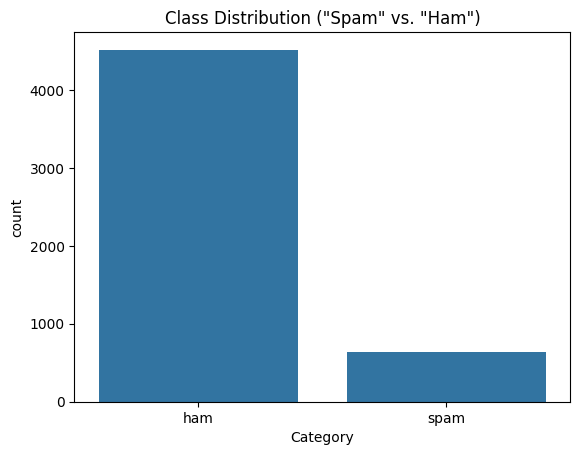

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class distribution
sns.countplot(x='Category', data=data)  # Specify 'x' for the categorical column
plt.title('Class Distribution ("Spam" vs. "Ham")')
plt.show()

In [7]:
!pip install nltk

In [8]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fuyingwang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
data['num_characters'] = data['Message'].apply(len)
data.head()

,Category,Message,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
# num of words
data['num_words'] = data['Message'].apply(lambda x:len(nltk.word_tokenize(x)))
data.head()

,Category,Message,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [11]:
data['num_sentences'] = data['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))
data.head()

,Category,Message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [12]:
data[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [13]:
# ham
data[data['Category'] == "ham"][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.267715,1.827724
std,56.708301,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [14]:
# spam
data[data['Category'] == "spam"][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.970359
std,30.399707,7.103501,1.485575
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

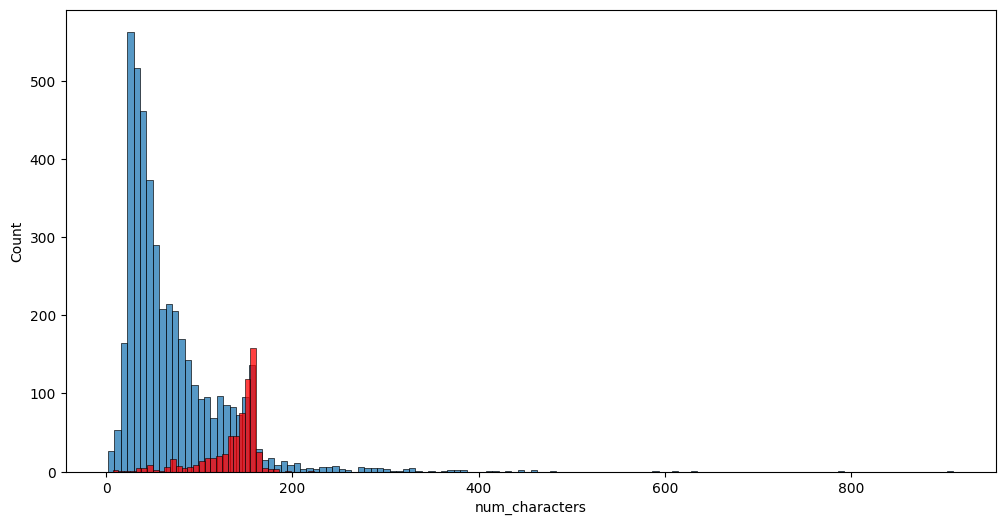

In [15]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['Category'] == "ham"]['num_characters'])
sns.histplot(data[data['Category'] == "spam"]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

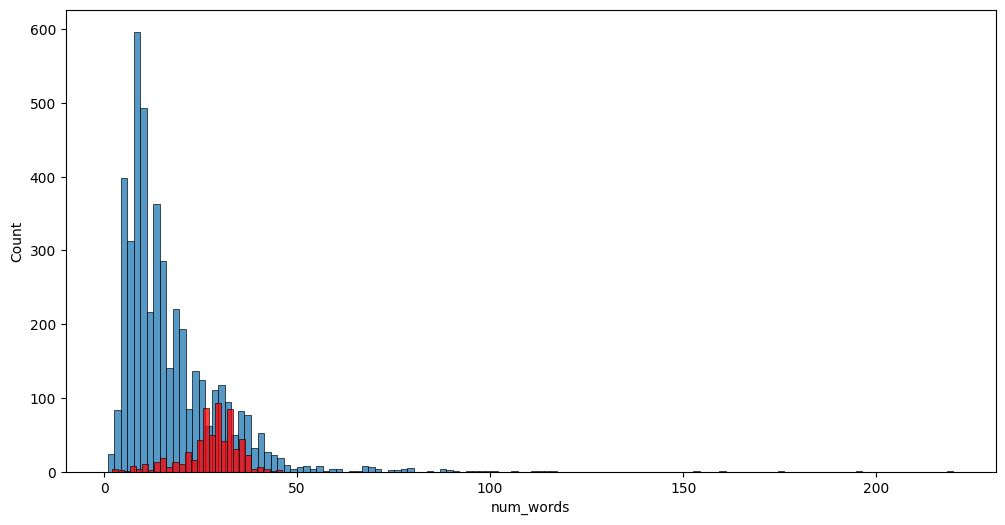

In [16]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['Category'] == "ham"]['num_words'])
sns.histplot(data[data['Category'] == "spam"]['num_words'],color='red')

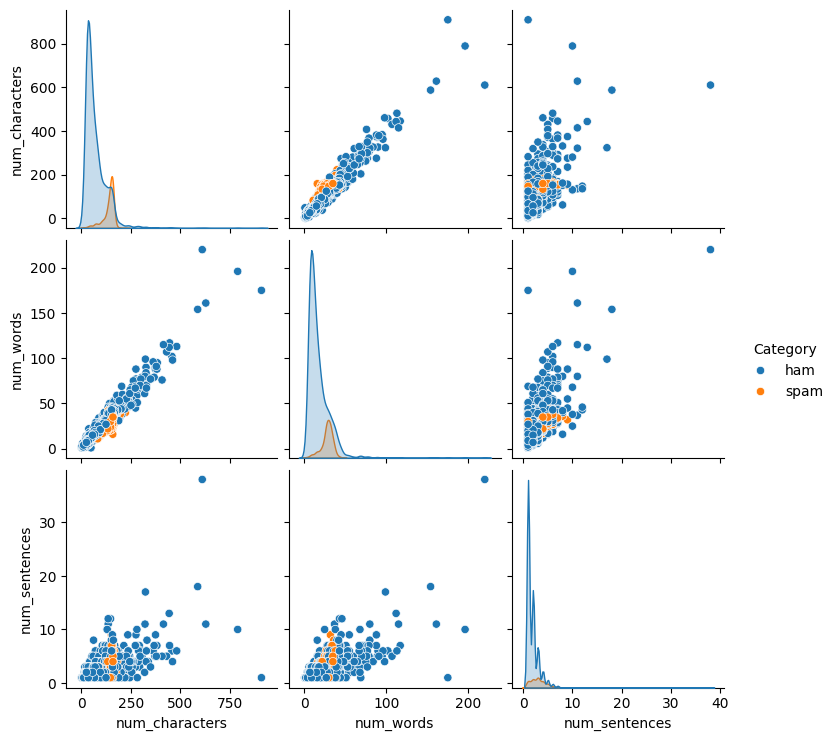

In [17]:
sns.pairplot(data, hue='Category')

### Catagorized the dataset label

In [18]:
data['spam'] = data['Category'].apply(lambda x: 1 if x == 'spam' else 0)
data.head()

,Category,Message,num_characters,num_words,num_sentences,spam
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,0
1,ham,Ok lar... Joking wif u oni...,29,8,2,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,1
3,ham,U dun say so early hor... U c already then say...,49,13,1,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,0


In [19]:
X = data['Message']
Y = data['spam']

print(X[:5])

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: object


In [20]:
print(Y[:5])

0    0
1    0
2    1
3    0
4    0
Name: spam, dtype: int64


In [21]:
data

,Category,Message,num_characters,num_words,num_sentences,spam
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,0
1,ham,Ok lar... Joking wif u oni...,29,8,2,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,1
3,ham,U dun say so early hor... U c already then say...,49,13,1,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,0
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,35,4,1
5568,ham,Will ü b going to esplanade fr home?,36,9,1,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2,0
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1,0


<Axes: >

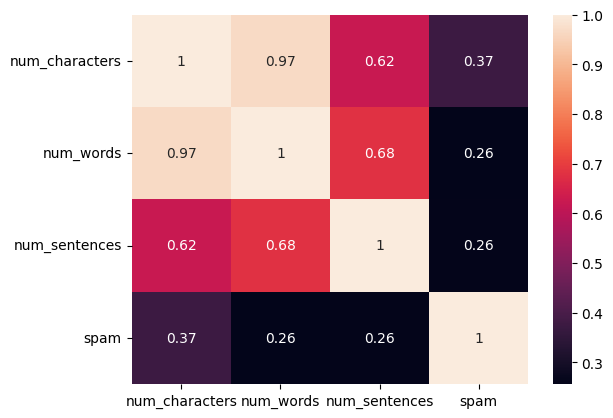

In [22]:
sns.heatmap(data.drop(columns=["Category", "Message"]).corr(),annot=True)

### Dataset Preprocessing

Here, we use a common text preprocessing pipeline: convert words into lowercase, remove punctuation, remove stop words.

In [23]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [24]:
data["Processed_Message"] = data["Message"].apply(transform_text)
data.head()

,Category,Message,num_characters,num_words,num_sentences,spam,Processed_Message
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,0,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,8,2,0,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,13,1,0,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,0,nah think goe usf live around though


In [25]:
! pip install wordcloud

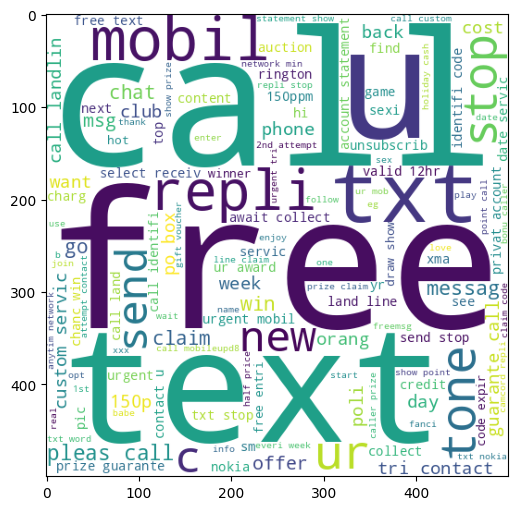

In [26]:
from wordcloud import WordCloud

wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

spam_wc = wc.generate(data[data['spam'] == 1]['Processed_Message'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

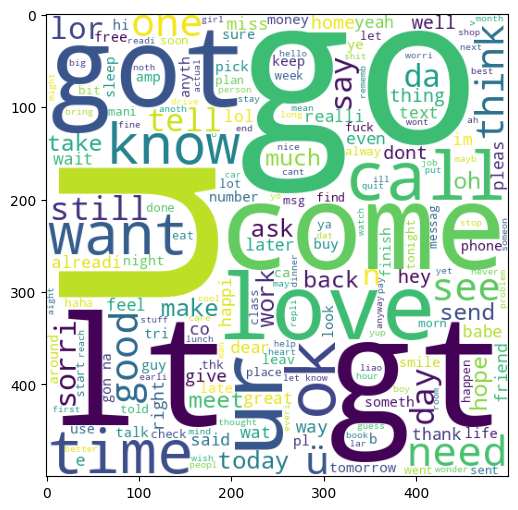

In [27]:
ham_wc = wc.generate(data[data['spam'] == 0]['Processed_Message'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

We can check some different characteristics between spam groups and ham groups:

In [28]:
from collections import Counter

# Separate spam and ham messages
spam_words = ' '.join(data[data['Category'] == 'spam']['Processed_Message']).split()
ham_words = ' '.join(data[data['Category'] == 'ham']['Processed_Message']).split()

# Get the most common words
spam_word_freq = Counter(spam_words).most_common(10)
ham_word_freq = Counter(ham_words).most_common(10)

print("Most Common Words in Spam Messages:\n", spam_word_freq)
print("Most Common Words in Ham Messages:\n", ham_word_freq)

Most Common Words in Spam Messages:
 [('call', 311), ('free', 186), ('2', 154), ('txt', 139), ('text', 122), ('ur', 119), ('u', 115), ('mobil', 110), ('stop', 108), ('repli', 103)]
Most Common Words in Ham Messages:
 [('u', 897), ('go', 407), ('get', 351), ('2', 288), ('gt', 288), ('lt', 287), ('come', 278), ('got', 239), ('know', 237), ('like', 236)]


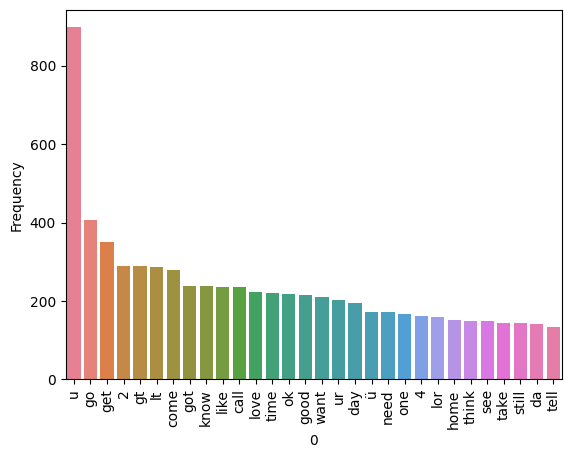

In [29]:
# For ham messages
sns.barplot(x=pd.DataFrame(Counter(ham_words).most_common(30))[0], y=pd.DataFrame(Counter(ham_words).most_common(30))[1],
            hue=pd.DataFrame(Counter(ham_words).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show()

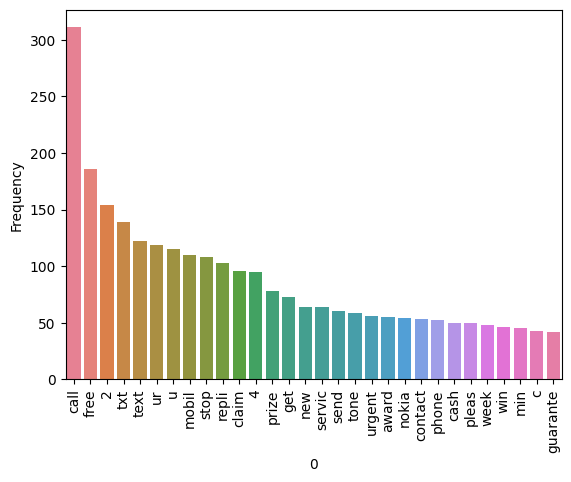

In [30]:
# For spam messages
sns.barplot(x=pd.DataFrame(Counter(spam_words).most_common(30))[0], y=pd.DataFrame(Counter(spam_words).most_common(30))[1],
            hue=pd.DataFrame(Counter(spam_words).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show()

### Train-test Split

Here we split the data into training, validation and testing sets with a ratio 60:20:20.

In [31]:
from sklearn.model_selection import train_test_split

# Split the dataset following the ratio of 60:20:20 for train, validation, and test set
# split the data into train & val and test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)
# split the train_val into train and val set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, stratify=y_train_val, test_size=0.2, random_state=42)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (3300,) (3300,)
Validation set: (825,) (825,)
Test set: (1032,) (1032,)


### Text Feature Extractor

Note that there are multiple ways to extract features from the text data. Here, we take the bag-of-words feature as an example, which calculate the counting number of each word as its feature, implemented by scikit-learn.(seen in https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*axffCQ9ae0FHXxhuy66FbA.png" width="1000">

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the training data
X_train_count = count_vectorizer.fit_transform(X_train)
X_train_count = X_train_count.toarray()
X_val_count = count_vectorizer.transform(X_val)
X_val_count = X_val_count.toarray()
X_test_count = count_vectorizer.transform(X_test)
X_test_count = X_test_count.toarray()

print("Shape of training set count matrix:", X_train_count.shape)
print("Shape of validation set count matrix:", X_val_count.shape)
print("Shape of testing set count matrix:", X_test_count.shape)

Shape of training set count matrix: (3300, 6730)
Shape of validation set count matrix: (825, 6730)
Shape of testing set count matrix: (1032, 6730)


### Model Design

For the model design, we will use these algorithms: 

* Logistic Regression
* Multinomial Naive Bayes Classifier
* Support Vecrot Machine Classifier with Radial basis function kernel (RBF)
* k Nearest Neighbor Classifier(KNN)
* Decision Tree Classifier
* Random Forest Classifier

#### Logistic Regression

Logistic regression is a supervised machine learning algorithm that accomplishes binary classification tasks by predicting the probability of an outcome, event, or observation. The model delivers a binary or dichotomous outcome limited to two possible outcomes: yes/no, 0/1, or true/false.

<img src="https://images.spiceworks.com/wp-content/uploads/2022/04/11040521/46-4-e1715636469361.png" width=800>

In [33]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_count, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_LR = log_reg.predict(X_test_count)
y_pred_LR_prob = log_reg.predict_proba(X_test_count)[:, 1]

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_LR)
precision = precision_score(y_test, y_pred_LR)
recall = recall_score(y_test, y_pred_LR)
f1 = f1_score(y_test, y_pred_LR)
print("Logistic Regression Model Evaluation Metrics")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Logistic Regression Model Evaluation Metrics
Accuracy: 0.9718992248062015
Precision: 0.9626168224299065
Recall: 0.8046875
F1 Score: 0.8765957446808511


#### Naive Bayes

Naive Bayes is a statistical classification technique based on Bayes Theorem. It is one of the simplest supervised learning algorithms. Naive Bayes classifier is the fast, accurate and reliable algorithm. Naive Bayes classifiers have high accuracy and speed on large datasets.

<img src="https://thatware.co/wp-content/uploads/2020/04/naive-bayes.png" width="1000">

Naive Bayes classifier assumes that the effect of a particular feature in a class is independent of other features. For example, a loan applicant is desirable or not depending on his/her income, previous loan and transaction history, age, and location. Even if these features are interdependent, these features are still considered independently. This assumption simplifies computation, and that's why it is considered as naive. This assumption is called class conditional independence.

In [36]:
from sklearn.naive_bayes import MultinomialNB

clf_NaiveBaised = MultinomialNB()

#Fiting the algorithm
clf_NaiveBaised.fit(X_train_count, y_train)

MultinomialNB()

In [37]:
# Make prediction on X_test
y_pred_NB = clf_NaiveBaised.predict(X_test_count)
y_pred_NB_prob = clf_NaiveBaised.predict_proba(X_test_count)[:, 1]

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_NB)
precision = precision_score(y_test, y_pred_NB)
recall = recall_score(y_test, y_pred_NB)
f1 = f1_score(y_test, y_pred_NB)
print("Evaluation Metrics for Naive Bayes Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Evaluation Metrics for Naive Bayes Classifier:
Accuracy: 0.9786821705426356
Precision: 0.9568965517241379
Recall: 0.8671875
F1 Score: 0.9098360655737705


<Axes: >

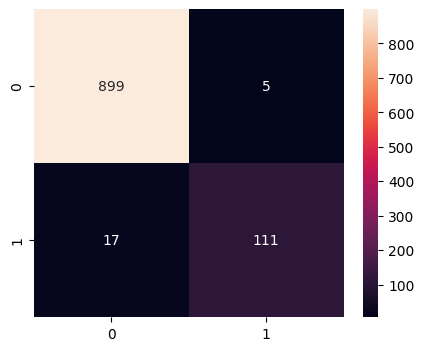

In [39]:
from sklearn.metrics import confusion_matrix

conf_mat_NB = confusion_matrix(y_test, y_pred_NB)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_NB, annot=True, fmt='d')

#### Support Vector Machines

Generally, Support Vector Machines is considered to be a classification approach, it but can be employed in both types of classification and regression problems. It can easily handle multiple continuous and categorical variables. SVM constructs a hyperplane in multidimensional space to separate different classes. SVM generates optimal hyperplane in an iterative manner, which is used to minimize an error. The core idea of SVM is to find a maximum marginal hyperplane(MMH) that best divides the dataset into classes.

<img src="https://vitalflux.com/wp-content/uploads/2022/08/support-vector-machine-1-640x354.png">

**SVM Kernels**: 

The SVM algorithm is implemented in practice using a kernel. A kernel transforms an input data space into the required form. SVM uses a technique called the kernel trick. Here, the kernel takes a low-dimensional input space and transforms it into a higher dimensional space. In other words, you can say that it converts nonseparable problem to separable problems by adding more dimension to it. It is most useful in non-linear separation problem. Kernel trick helps you to build a more accurate classifier.

<img src="https://miro.medium.com/v2/resize:fit:1254/format:webp/1*_Uhpj662QpxoIa8qlPYJ9A.png">

In [40]:
from sklearn.svm import SVC

clf_SVM = SVC(kernel="rbf", C=1000, gamma=0.001)
clf_SVM.fit(X_train_count, y_train)

SVC(C=1000, gamma=0.001)

In [41]:
# Make prediction on X_test
y_pred_svm = clf_SVM.predict(X_test_count)
y_pred_svm_prob = clf_SVM.decision_function(X_test_count)

In [42]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)
print("Evaluation Metrics for Naive Bayes Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Evaluation Metrics for Naive Bayes Classifier:
Accuracy: 0.9738372093023255
Precision: 0.963302752293578
Recall: 0.8203125
F1 Score: 0.8860759493670886


<Axes: >

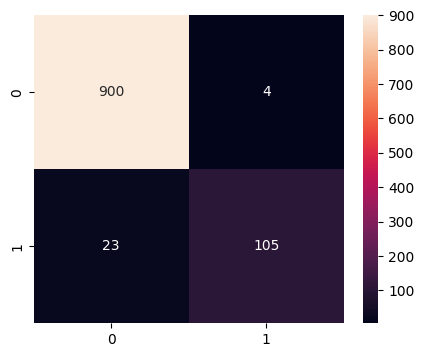

In [43]:
from sklearn.metrics import confusion_matrix

conf_mat_NB = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_NB, annot=True, fmt='d')

#### K Nearest Neighbor Classifier (KNN)

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*34SajbTO2C5Lvigs.png">

In [44]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier(n_neighbors=3)
clf_knn.fit(X_train_count, y_train)

KNeighborsClassifier(n_neighbors=3)

In [45]:
y_pred_knn = clf_knn.predict(X_test_count)
y_pred_knn_prob = clf_knn.predict_proba(X_test_count)[:, 1]

In [46]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
print("Evaluation Metrics for K-Nearest Neighbors Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Evaluation Metrics for K-Nearest Neighbors Classifier:
Accuracy: 0.9215116279069767
Precision: 1.0
Recall: 0.3671875
F1 Score: 0.5371428571428571


<Axes: >

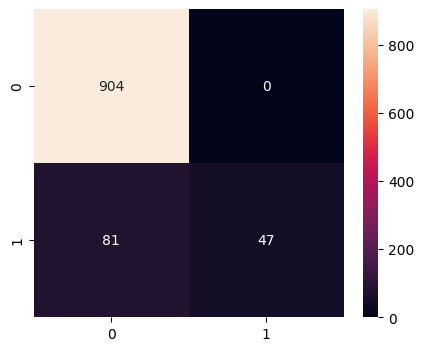

In [47]:
# plot confusion matrix
conf_mat_NB = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_NB, annot=True, fmt='d')

#### Decision Tree Classifier

A decision tree is a flowchart-like tree structure where an internal node represents feature(or attribute), the branch represents a decision rule, and each leaf node represents the outcome. The topmost node in a decision tree is known as the root node. It learns to partition on the basis of the attribute value. It partitions the tree in recursively manner call recursive partitioning. This flowchart-like structure helps you in decision making. It's visualization like a flowchart diagram which easily mimics the human level thinking. That is why decision trees are easy to understand and interpret.

<img src="https://dataaspirant.com/wp-content/uploads/2017/01/B03905_05_01-compressor.png" width="1000">

In [48]:
from sklearn.tree import DecisionTreeClassifier

clf_dt = DecisionTreeClassifier()
clf_dt.fit(X_train_count, y_train)

DecisionTreeClassifier()

In [49]:
y_pred_dt = clf_dt.predict(X_test_count)
y_pred_dt_prob = clf_dt.predict_proba(X_test_count)[:, 1]

In [50]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
print("Evaluation Metrics for Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Evaluation Metrics for Decision Tree Classifier:
Accuracy: 0.9612403100775194
Precision: 0.8793103448275862
Recall: 0.796875
F1 Score: 0.8360655737704918


<Axes: >

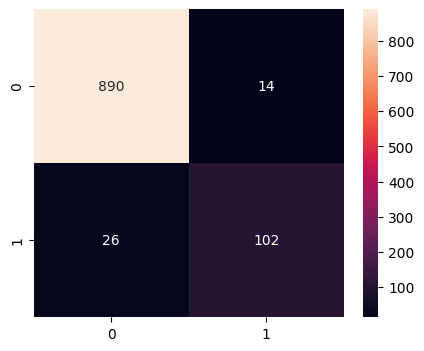

In [51]:
# plot confusion matrix

conf_mat_NB = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_NB, annot=True, fmt='d')

#### Random Forest Classifier (RF)

What is a random forest?

A random forest is a machine learning technique that’s used to solve regression and classification problems. It utilizes ensemble learning, which is a technique that combines many classifiers to provide solutions to complex problems.

A random forest algorithm consists of many decision trees. The ‘forest’ generated by the random forest algorithm is trained through bagging or bootstrap aggregating. Bagging is an ensemble meta-algorithm that improves the accuracy of machine learning algorithms.

The (random forest) algorithm establishes the outcome based on the predictions of the decision trees. It predicts by taking the average or mean of the output from various trees. Increasing the number of trees increases the precision of the outcome.

A random forest eradicates the limitations of a decision tree algorithm. It reduces the overfitting of datasets and increases precision.

<img src="https://miro.medium.com/v2/resize:fit:1184/format:webp/1*i0o8mjFfCn-uD79-F1Cqkw.png" width=500>

In [52]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_count, y_train)

RandomForestClassifier(random_state=42)

In [53]:
# Make prediction on X_test
y_pred_rf = clf_rf.predict(X_test_count)
y_pred_rf_prob = clf_rf.predict_proba(X_test_count)[:, 1]

In [54]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
print("Evaluation Metrics for Random Forest Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Evaluation Metrics for Random Forest Classifier:
Accuracy: 0.9660852713178295
Precision: 0.9894736842105263
Recall: 0.734375
F1 Score: 0.8430493273542601


<Axes: >

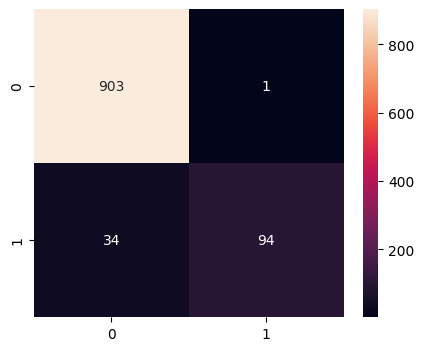

In [55]:
# plot confusion matrix
conf_mat_NB = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_NB, annot=True, fmt='d')

### Result Comparison

In [56]:
# Here we summarize the results of all the classifiers
from sklearn.metrics import roc_auc_score, average_precision_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_LR),
                 accuracy_score(y_test, y_pred_NB), accuracy_score(y_test, y_pred_svm),
                 accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_LR),
                  precision_score(y_test, y_pred_NB), precision_score(y_test, y_pred_svm),
                  precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_dt),
                  precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_LR),
               recall_score(y_test, y_pred_NB), recall_score(y_test, y_pred_svm),
               recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_dt),
               recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_LR),
                 f1_score(y_test, y_pred_NB), f1_score(y_test, y_pred_svm),
                 f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_dt),
                 f1_score(y_test, y_pred_rf)],
    'AUROC': [roc_auc_score(y_test, y_pred_LR_prob),
              roc_auc_score(y_test, y_pred_NB_prob), roc_auc_score(y_test, y_pred_svm_prob),
              roc_auc_score(y_test, y_pred_knn_prob), roc_auc_score(y_test, y_pred_dt_prob),
              roc_auc_score(y_test, y_pred_rf_prob)],
    'AUPRC': [average_precision_score(y_test, y_pred_LR_prob),
              average_precision_score(y_test, y_pred_NB_prob), average_precision_score(y_test, y_pred_svm_prob),
              average_precision_score(y_test, y_pred_knn_prob), average_precision_score(y_test, y_pred_dt_prob),
              average_precision_score(y_test, y_pred_rf_prob)]
})

results.index = results['Model'].values
results.drop(columns='Model', inplace=True)
results.sort_values(by=["AUROC", "AUPRC"], ascending=True, inplace=True)
print(results)

                     Accuracy  Precision    Recall  F1 Score     AUROC  \
KNN                  0.921512   1.000000  0.367188  0.537143  0.776294   
Decision Tree        0.961240   0.879310  0.796875  0.836066  0.890694   
Naive Bayes          0.978682   0.956897  0.867188  0.909836  0.966615   
Logistic Regression  0.971899   0.962617  0.804688  0.876596  0.970850   
SVM                  0.973837   0.963303  0.820312  0.886076  0.973525   
Random Forest        0.966085   0.989474  0.734375  0.843049  0.985555   

                        AUPRC  
KNN                  0.602319  
Decision Tree        0.725894  
Naive Bayes          0.937965  
Logistic Regression  0.932776  
SVM                  0.937599  
Random Forest        0.956226  


<Axes: >

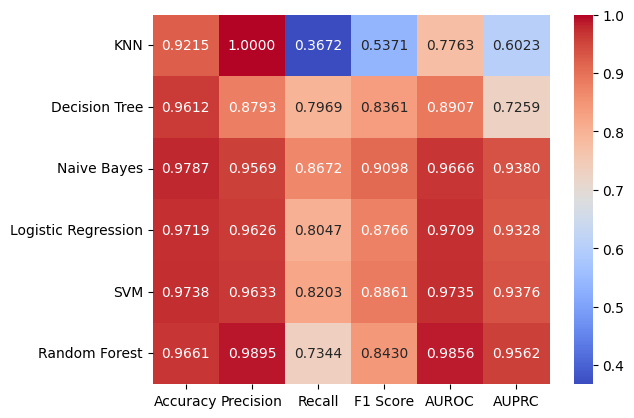

In [57]:
sns.heatmap(results, annot=True, fmt='.4f', cmap='coolwarm')

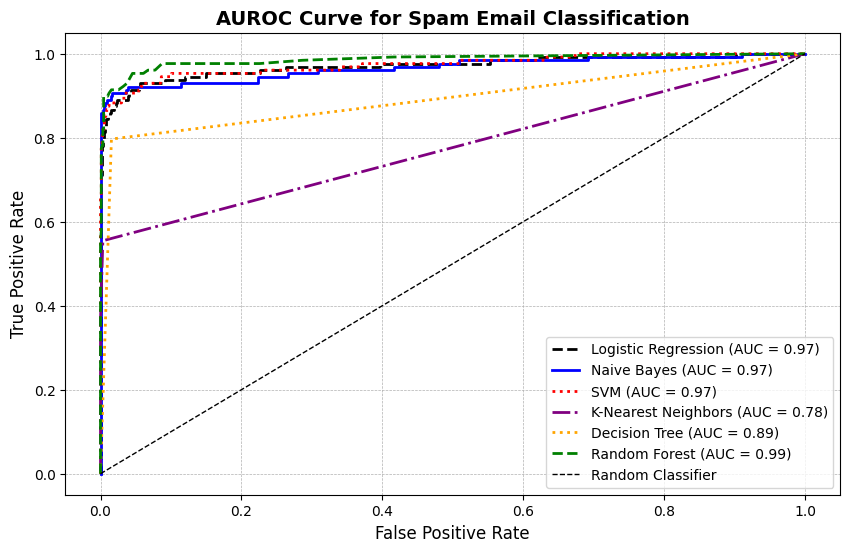

In [58]:
# plot ROC curve

from sklearn.metrics import roc_curve, auc

# Calculate ROC and AUC values for each model
fpr_LR, tpr_LR, _ = roc_curve(y_test, y_pred_LR_prob)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_NB_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)

auc_LR = auc(fpr_LR, tpr_LR)
auc_nb = auc(fpr_nb, tpr_nb)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot AUROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_LR, tpr_LR, label=f"Logistic Regression (AUC = {auc_LR:.2f})", color="black", linestyle="dashed", linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})", color="blue", linestyle="-", linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})", color="red", linestyle="dotted", linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f"K-Nearest Neighbors (AUC = {auc_knn:.2f})", color="purple", linestyle="-.", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})", color="orange", linestyle=":", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})", color="green", linestyle="--", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Random Classifier")  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AUROC Curve for Spam Email Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(visible=True, linestyle='--', linewidth=0.5)
plt.show()


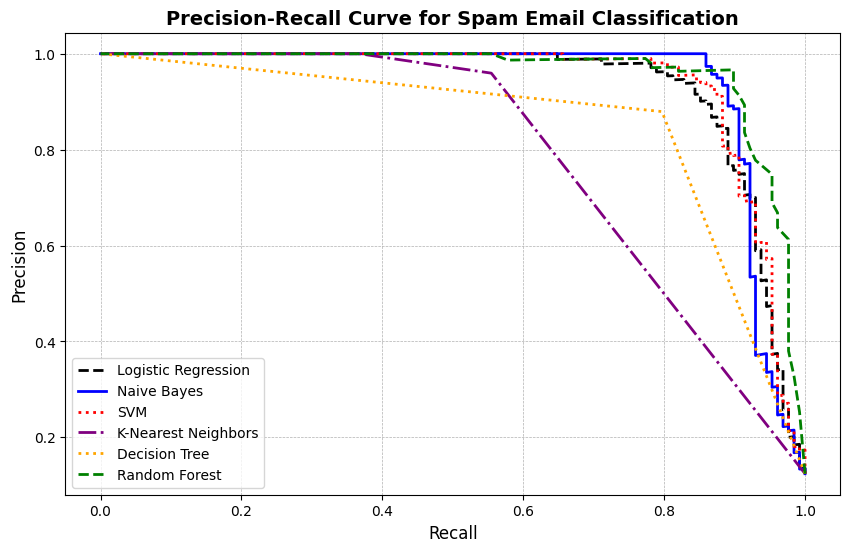

In [59]:
# plot Precision-Recall curve
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall values
precision_LR, recall_LR, _ = precision_recall_curve(y_test, y_pred_LR_prob)
precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_pred_NB_prob)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_pred_svm_prob)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_pred_knn_prob)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_dt_prob)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall_LR, precision_LR, label="Logistic Regression", color="black", linestyle="dashed", linewidth=2)
plt.plot(recall_nb, precision_nb, label="Naive Bayes", color="blue", linestyle="-", linewidth=2)
plt.plot(recall_svm, precision_svm, label="SVM", color="red", linestyle="dotted", linewidth=2)
plt.plot(recall_knn, precision_knn, label="K-Nearest Neighbors", color="purple", linestyle="-.", linewidth=2)
plt.plot(recall_dt, precision_dt, label="Decision Tree", color="orange", linestyle=":", linewidth=2)
plt.plot(recall_rf, precision_rf, label="Random Forest", color="green", linestyle="--", linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve for Spam Email Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(visible=True, linestyle='--', linewidth=0.5)
plt.show()

<Axes: title={'center': 'Random Forest'}>

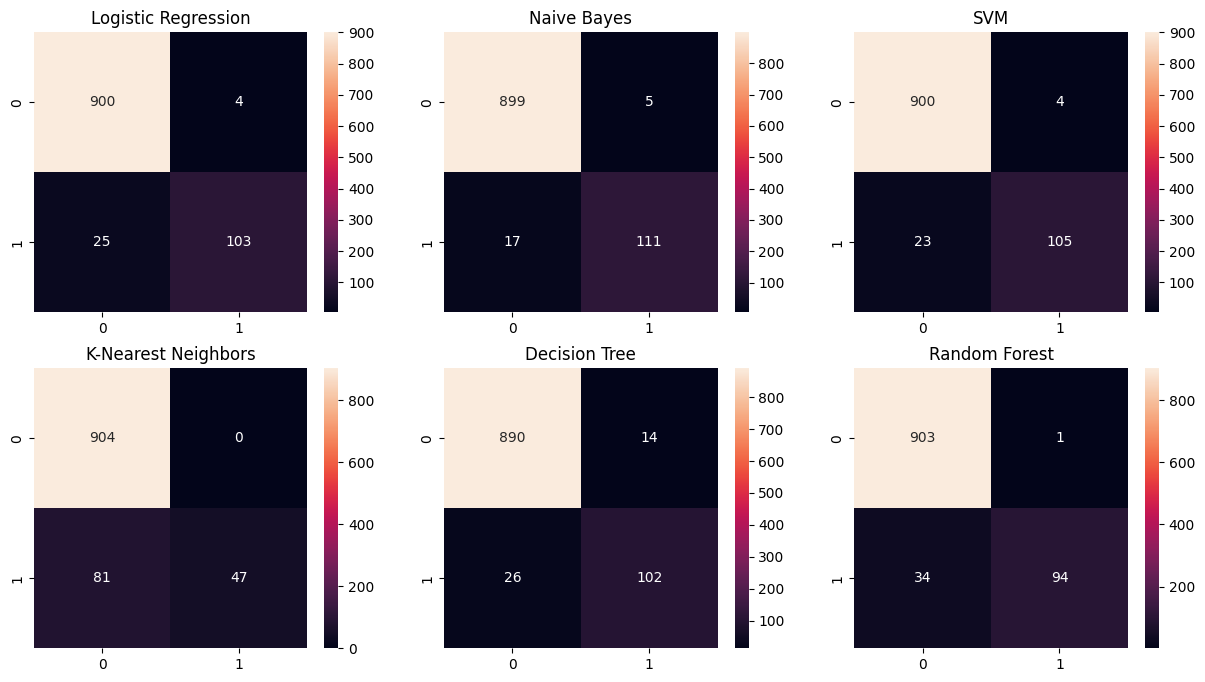

In [60]:
# comparison of confusion matrices

conf_mat_LR = confusion_matrix(y_test, y_pred_LR)
conf_mat_NB = confusion_matrix(y_test, y_pred_NB)
conf_mat_svm = confusion_matrix(y_test, y_pred_svm)
conf_mat_knn = confusion_matrix(y_test, y_pred_knn)
conf_mat_dt = confusion_matrix(y_test, y_pred_dt)
conf_mat_rf = confusion_matrix(y_test, y_pred_rf)
conf_mat_gt = confusion_matrix(y_test, y_test)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].set_title("Logistic Regression")
axes[1].set_title("Naive Bayes")
axes[2].set_title("SVM")
axes[3].set_title("K-Nearest Neighbors")
axes[4].set_title("Decision Tree")
axes[5].set_title("Random Forest")

sns.heatmap(conf_mat_LR, annot=True, fmt='d', ax=axes[0])
sns.heatmap(conf_mat_NB, annot=True, fmt='d', ax=axes[1])
sns.heatmap(conf_mat_svm, annot=True, fmt='d', ax=axes[2])
sns.heatmap(conf_mat_knn, annot=True, fmt='d', ax=axes[3])
sns.heatmap(conf_mat_dt, annot=True, fmt='d', ax=axes[4])
sns.heatmap(conf_mat_rf, annot=True, fmt='d', ax=axes[5])

### Interpreting Models

In [61]:
!pip install graphviz

##### Visualizaing decision tree:

In [62]:
import graphviz
import sklearn.tree

dot_data = sklearn.tree.export_graphviz(clf_dt, out_file=None,
                                        feature_names = list(count_vectorizer.vocabulary_.keys()),
                                        filled = True)
 
graph = graphviz.Source(dot_data)
 
# saving tree to png file
png_bytes = graph.pipe(format='png')
with open('decision_tree.png','wb') as f:
    f.write(png_bytes)

<img src="./decision_tree.png" width=1000>

##### Feature Importance for Random Forest

Text(0.5, 1.0, 'Top 20 Important Features for Random Forest Classifier')

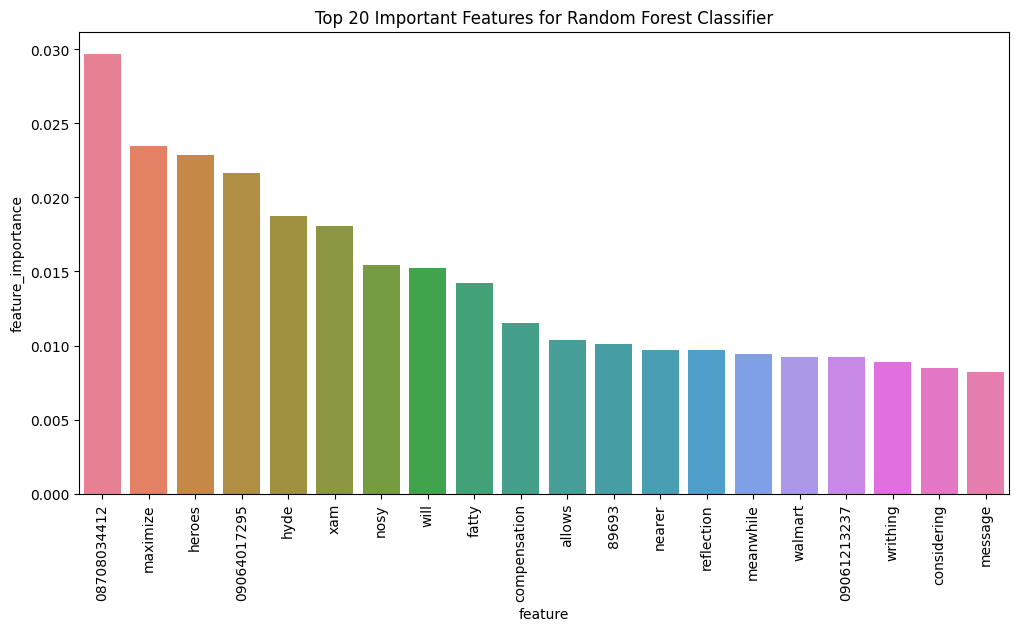

In [63]:
threshold = None
feature_importance_df = pd.DataFrame.from_dict({'feature_importance': clf_rf.feature_importances_,
                                                'feature': list(count_vectorizer.vocabulary_.keys())})\
        .set_index('feature').sort_values('feature_importance', ascending = False)

feature_importance_df.sort_values('feature_importance', ascending=False, inplace=True)
feature_importance_df = feature_importance_df.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    x=feature_importance_df.index,
    y=feature_importance_df['feature_importance'],
    hue=feature_importance_df.index,
)
plt.xticks(rotation=90)
plt.title('Top 20 Important Features for Random Forest Classifier')

##### Visualize support vectors

In [64]:
# Get number of support vectors per class
support_vectors_per_class = clf_SVM.n_support_
print(support_vectors_per_class)

[397 172]


In [65]:
!pip install umap-learn

In [69]:
import umap

# Reduce the dimensionality of the data to 2D
umap_model = umap.UMAP(n_components=2).fit(X_train_count)
X_train_count_umap = umap_model.transform(X_train_count)
support_vectors_umap = umap_model.transform(clf_SVM.support_vectors_)

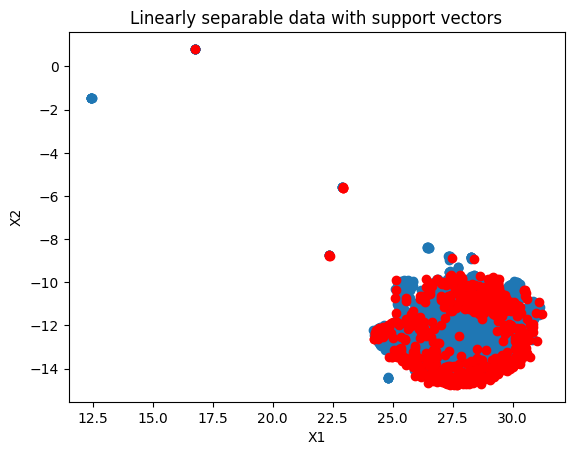

In [70]:
support_vectors = clf_SVM.support_vectors_

# Visualize support vectors
plt.scatter(X_train_count_umap[:, 0], X_train_count_umap[:, 1])
plt.scatter(support_vectors_umap[:, 0], support_vectors_umap[:, 1], color='red')
plt.title('Linearly separable data with support vectors')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()